In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

PyTorch: 2.12.1+cpu
Pandas: 1.5.3
NumPy: 1.26.4


In [2]:
df = pd.read_hdf("metr-la.h5")

print(df.shape)
df.head()

(34272, 207)


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [3]:
data = df.values

print(data.shape)

print("Min:", data.min())
print("Max:", data.max())
print("Mean:", data.mean())

(34272, 207)
Min: 0.0
Max: 70.0
Mean: 53.71902110241344


In [4]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

print(data_scaled.shape)

(34272, 207)


In [5]:
SEQ_LEN = 12
PRED_LEN = 12

X = []
y = []

for i in range(len(data_scaled) - SEQ_LEN - PRED_LEN):

    X.append(
        data_scaled[i:i+SEQ_LEN]
    )

    y.append(
        data_scaled[
            i+SEQ_LEN :
            i+SEQ_LEN+PRED_LEN
        ]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(34248, 12, 207)
(34248, 12, 207)


In [6]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.1)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[
    train_size:
    train_size+val_size
]

y_val = y[
    train_size:
    train_size+val_size
]

X_test = X[
    train_size+val_size:
]

y_test = y[
    train_size+val_size:
]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(23973, 12, 207)
(3424, 12, 207)
(6851, 12, 207)


In [7]:
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [8]:
batch_size = 64

train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [9]:
class MultiStepLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=207,
            hidden_size=128,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            128,
            207
        )

    def forward(self, x):

        out, _ = self.lstm(x)

        out = self.fc(out)

        return out

In [10]:
model = MultiStepLSTM()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

MultiStepLSTM(
  (lstm): LSTM(207, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=207, bias=True)
)


In [11]:
import time

train_start = time.time()

In [12]:
epochs = 30

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(
            X_batch
        )

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = (
        total_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch+1}/{epochs}"
        f" Loss: {avg_loss:.6f}"
    )

Epoch 1/30 Loss: 0.068944
Epoch 2/30 Loss: 0.050316
Epoch 3/30 Loss: 0.047037
Epoch 4/30 Loss: 0.045108
Epoch 5/30 Loss: 0.042889
Epoch 6/30 Loss: 0.041894
Epoch 7/30 Loss: 0.041140
Epoch 8/30 Loss: 0.040627
Epoch 9/30 Loss: 0.040227
Epoch 10/30 Loss: 0.039826
Epoch 11/30 Loss: 0.039389
Epoch 12/30 Loss: 0.038824
Epoch 13/30 Loss: 0.038462
Epoch 14/30 Loss: 0.038122
Epoch 15/30 Loss: 0.037885
Epoch 16/30 Loss: 0.037783
Epoch 17/30 Loss: 0.037550
Epoch 18/30 Loss: 0.037242
Epoch 19/30 Loss: 0.036886
Epoch 20/30 Loss: 0.036606
Epoch 21/30 Loss: 0.036376
Epoch 22/30 Loss: 0.036135
Epoch 23/30 Loss: 0.035990
Epoch 24/30 Loss: 0.035914
Epoch 25/30 Loss: 0.035843
Epoch 26/30 Loss: 0.035480
Epoch 27/30 Loss: 0.035338
Epoch 28/30 Loss: 0.035041
Epoch 29/30 Loss: 0.034869
Epoch 30/30 Loss: 0.034641


In [13]:
train_time = time.time() - train_start

print("Time Taken:", train_time)

Time Taken: 1777.6270735263824


In [14]:
torch.save(
    model.state_dict(),
    "MultiStepLSTM-METRLa.pth"
)

In [15]:
model.eval()

infer_start = time.time()

with torch.no_grad():

    predictions = model(
        X_test
    )
    


predictions = predictions.numpy()

infer_time = time.time() - infer_start
print("Infer Time:", infer_time)
true_values = y_test.numpy()

predictions = predictions.reshape(-1, 207)
true_values = true_values.reshape(-1, 207)

mae = mean_absolute_error(
    true_values,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        true_values,
        predictions
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

Infer Time: 0.7159883975982666
MAE: 0.14277798
RMSE: 0.24009587


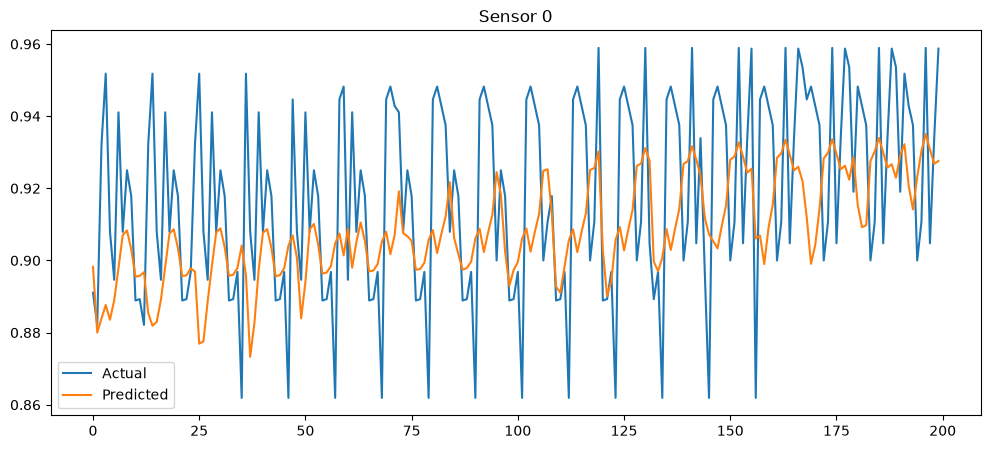

In [16]:
import matplotlib.pyplot as plt

sensor = 0

plt.figure(figsize=(12,5))

plt.plot(
    true_values[:200, sensor],
    label="Actual"
)

plt.plot(
    predictions[:200, sensor],
    label="Predicted"
)

plt.legend()

plt.title(
    f"Sensor {sensor}"
)

plt.show()

In [17]:
from sklearn.metrics import r2_score

mape = np.mean(
    np.abs((true_values - predictions) /
           np.maximum(np.abs(true_values), 1e-6))
) * 100

r2 = r2_score(
    true_values.flatten(),
    predictions.flatten()
)
print("MAPE:", mape)
print("R2:", r2)

MAPE: 4363710.9375
R2: 0.45563401476952536


In [18]:
params = sum(
    p.numel()
    for p in model.parameters()
)

print("Parameters:", params)

Parameters: 331343
